Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Randomly generating line, logging m & c

In [2]:
rng = np.random.default_rng()
truem = 5 * rng.random()
truec = 5 * rng.random()

print(f"true m: {truem}")
print(f"true c: {truec}")

X = np.arange(0,1,.01)
rand = rng.random(100)
rand = 2*(rand-0.5)
Y = truem*X+truec+rand

true m: 1.464315681430997
true c: 0.7264647732919977


# Using Numpy Least Squares Algorithm

Calculating using previous code

In [3]:
# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T

# Solve using least squares
m1, c1 = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m1}, Intercept: {c1}")

Slope: 1.6315314210502916, Intercept: 0.6601146888377554


Plotting

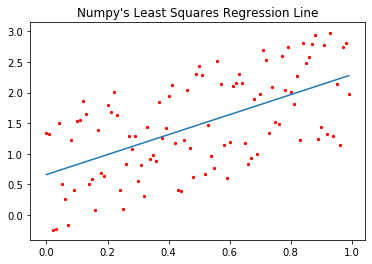

In [4]:
plt.scatter(X,Y,5,"r")
plt.plot(X,m1*X+c1)
plt.title("Numpy's Least Squares Regression Line")
plt.show()

Printing residuals

In [5]:
resid = Y-(m1*X+c1)
print(resid)

[ 0.6830314   0.64125553 -0.93164892 -0.93064007  0.78043134 -0.23246181
 -0.50458756 -0.93706023  0.42581391 -0.3933906   0.71415213  0.71127284
  1.00111199  0.77890881 -0.37865879 -0.32455563 -0.8378336   0.45083369
 -0.2721647  -0.32670493  0.81605125  0.67766078  0.98623128  0.59619765
 -0.64717536 -0.96648501 -0.25195023  0.19246229 -0.04556839  0.16062506
 -0.60267337 -0.34800932 -0.86881188  0.2325706  -0.29810839 -0.25701495
 -0.36954651  0.57434637 -0.02671028  0.12748283  0.62322203  0.79671491
 -0.17421817 -0.95583772 -0.9830928  -0.1669151   0.63731185 -0.32506793
 -0.81906723  0.84025614  0.96071837  0.79543962 -0.83376537 -0.05636378
 -0.58492692 -0.7847603   0.93543716  0.54732309 -0.46677255 -1.01809429
 -0.44520817  0.44774161  0.48866964  0.62102567  0.44413469 -0.552766
 -0.90348251 -0.81678697  0.12316812 -0.79135314  0.16833884  0.88354856
  0.69397565 -0.50788252  0.22248123 -0.37110613 -0.40708325  0.67916009
  0.10758902  0.79529045  0.0374051  -0.17637392  0.2

Printing max and min residuals

In [6]:
print(f"Max residual: {resid.max()} at x value of {X[np.argmax(resid)]}")
print(f"Min residual: {resid.min()} at x value of {X[np.argmin(resid)]}")

Max residual: 1.0011119882249089 at x value of 0.12
Min residual: -1.0790633452323377 at x value of 0.96


# Using My Least Squares algorithm

Coding the algorithm

In [7]:
def leastsquare(xs,ys):
    sum1 = np.sum(xs)
    sum2 = np.sum(ys)
    sum3 = np.sum(xs*xs)
    sum4 = np.sum(xs*ys)
    n = len(xs)
    m = (n*sum4-sum1*sum2)/(n*sum3-sum1**2)
    c = (sum2-m*sum1)/n
    return(m,c)

Applying my algorithm to the data

In [8]:
m2,c2 = leastsquare(X,Y)
print(f"Slope: {m2}, Intercept: {c2}")

Slope: 1.6315314210502931, Intercept: 0.6601146888377555


Plotting my algorithm's line

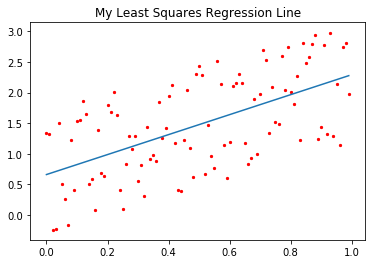

In [9]:
plt.scatter(X,Y,5,"r")
plt.plot(X,m2*X+c2)
plt.title("My Least Squares Regression Line")
plt.show()

Finding the difference between my equation and the numpy equation

In [10]:
print(f"m difference: {m1-m2}")
print(f"c difference: {c1-c2}")

m difference: -1.5543122344752192e-15
c difference: -1.1102230246251565e-16


# The Same Thing but with Random Vectors

Making random vectors

In [11]:
X1 = rng.random(5)
X1 = 5*X1
X1.sort()

Y1 = rng.random(5)
Y1 = 5*Y1

Calculating and plotting using numpy's least squares

Slope: 0.008728073144659848, Intercept: 4.433333833992152


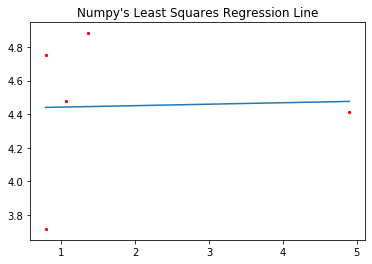

In [12]:
# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X1, np.ones(len(X1))]).T

# Solve using least squares
m1, c1 = np.linalg.lstsq(A, Y1, rcond=None)[0]
print(f"Slope: {m1}, Intercept: {c1}")

plt.scatter(X1,Y1,5,"r")
plt.plot(X1,m1*X1+c1)
plt.title("Numpy's Least Squares Regression Line")
plt.show()

Calculating and plotting my least squares

Slope: 0.008728073144661347, Intercept: 4.433333833992148


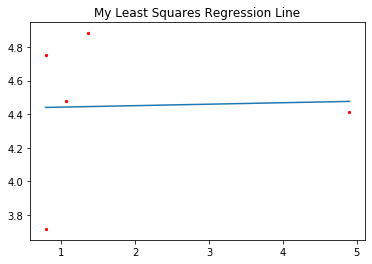

In [13]:
m2,c2 = leastsquare(X1,Y1)
print(f"Slope: {m2}, Intercept: {c2}")

plt.scatter(X1,Y1,5,"r")
plt.plot(X1,m2*X1+c2)
plt.title("My Least Squares Regression Line")
plt.show()

Finding the difference between the two equations

In [14]:
print(f"m difference: {m1-m2}")
print(f"c difference: {c1-c2}")

m difference: -1.4988010832439613e-15
c difference: 3.552713678800501e-15


# Commentary

As can be seen above, the algorithm I coded from the formula in the lecture is not far off from numpy's, only varying by a number on the order of 10^-15. Because of this, the resulting equations are almost exactly alike. However, if I had to guess the numpy calculations were a lot faster than my unoptomized programming.